In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [3]:
df = pd.read_csv("data/sales_history.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,sku,units_sold,promo_flag
0,2024-12-16,FIL-1001,30,0
1,2024-12-23,FIL-1001,23,0
2,2024-12-30,FIL-1001,22,0
3,2025-01-06,FIL-1001,14,0
4,2025-01-13,FIL-1001,22,0


In [4]:
print(df.shape)
print(df["sku"].nunique())

df.groupby("sku").size().head()

(2340, 4)
30


sku
BRK-1015    78
BRK-1036    78
BRK-1040    78
BRK-1041    78
BRK-1054    78
dtype: int64

In [ ]:
for lag in [1, 2, 3, 4]:
    df[f"lag_{lag}"] = (
        df.groupby("sku")["units_sold"]
          .shift(lag)
    )


df["rolling_mean_4"] = (
    df.groupby("sku")["units_sold"]
      .shift(1)
      .rolling(4)
      .mean()
)

model_df = df.dropna().copy()

model_df.head()

,date,sku,units_sold,promo_flag,lag_1,lag_2,lag_3,lag_4,rolling_mean_4
4,2025-01-13,FIL-1001,22,0,14.0,22.0,23.0,30.0,22.25
5,2025-01-20,FIL-1001,60,1,22.0,14.0,22.0,23.0,20.25
6,2025-01-27,FIL-1001,22,0,60.0,22.0,14.0,22.0,29.50
7,2025-02-03,FIL-1001,21,0,22.0,60.0,22.0,14.0,29.50
8,2025-02-10,FIL-1001,26,0,21.0,22.0,60.0,22.0,31.25


In [9]:
test_idx = (
    model_df.groupby("sku")
            .tail(4)
            .index
)

test_df = model_df.loc[test_idx]
train_df = model_df.drop(test_idx)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (2100, 9)
Test: (120, 9)


In [10]:
from sklearn.metrics import mean_absolute_error

baseline_pred = test_df["rolling_mean_4"]

baseline_mae = mean_absolute_error(
    test_df["units_sold"],
    baseline_pred
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 7.858333333333333


In [11]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "rolling_mean_4",
    "promo_flag"
]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(
    train_df[features],
    train_df["units_sold"]
)

preds = model.predict(
    test_df[features]
)

rf_mae = mean_absolute_error(
    test_df["units_sold"],
    preds
)

print("RF MAE:", rf_mae)

RF MAE: 5.630663525132276


In [12]:
results = pd.DataFrame({
    "Model": ["Moving Average Baseline", "Random Forest"],
    "MAE": [baseline_mae, rf_mae]
})

results

,Model,MAE
0,Moving Average Baseline,7.858333
1,Random Forest,5.630664


In [13]:
improvement = (
    (baseline_mae - rf_mae)
    / baseline_mae
) * 100

print(f"Improvement: {improvement:.2f}%")

Improvement: 28.35%


In [20]:
results = pd.DataFrame({
    "Model": ["Moving Average Baseline", "Random Forest"],
    "MAE": [baseline_mae, rf_mae]
})

results["Improvement_vs_Baseline"] = [
    "0%",
    f"{((baseline_mae-rf_mae)/baseline_mae)*100:.2f}%"
]

results

,Model,MAE,Improvement_vs_Baseline
0,Moving Average Baseline,7.858333,0%
1,Random Forest,5.630664,28.35%


In [15]:
sku_results = (
    test_df.assign(pred=preds)
    .groupby("sku")
    .apply(
        lambda x: mean_absolute_error(
            x["units_sold"],
            x["pred"]
        )
    )
    .reset_index(name="MAE")
)

sku_results.sort_values("MAE")
sku_results.describe()

,MAE
count,30.000000
mean,5.630664
std,3.346087
min,1.564843
25%,3.584844
50%,4.445000
75%,6.640000
max,18.151250


In [16]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

rolling_mean_4    0.687114
promo_flag        0.164107
lag_1             0.045202
lag_2             0.039982
lag_3             0.031952
lag_4             0.031643
dtype: float64

Matplotlib is building the font cache; this may take a moment.


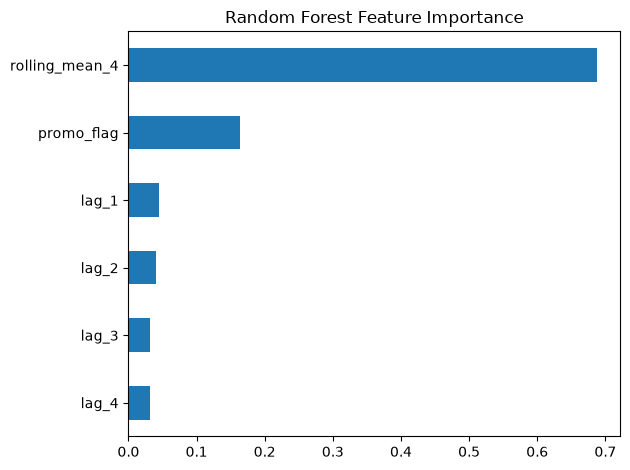

In [18]:
import matplotlib.pyplot as plt

importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [19]:
comparison = test_df.copy()

comparison["predicted"] = preds

comparison[[
    "sku",
    "date",
    "units_sold",
    "predicted"
]].head(20)

,sku,date,units_sold,predicted
74,FIL-1001,2026-05-18,23,20.6685
75,FIL-1001,2026-05-25,10,18.6300
76,FIL-1001,2026-06-01,17,16.9700
77,FIL-1001,2026-06-08,14,15.2750
152,CHN-1023,2026-05-18,30,23.5050
153,CHN-1023,2026-05-25,18,23.2550
154,CHN-1023,2026-06-01,22,19.3200
155,CHN-1023,2026-06-08,20,21.0250
230,FIL-1042,2026-05-18,29,28.2200
231,FIL-1042,2026-05-25,23,28.2000


In [21]:
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

final_model.fit(
    model_df[features],
    model_df["units_sold"]
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [22]:
def forecast_next_4_weeks(df, sku, model):

    sku_df = (
        df[df["sku"] == sku]
        .sort_values("date")
    )

    history = list(
        sku_df["units_sold"].values
    )

    forecasts = []

    for _ in range(4):

        lag_1 = history[-1]
        lag_2 = history[-2]
        lag_3 = history[-3]
        lag_4 = history[-4]

        rolling_mean_4 = (
            lag_1 +
            lag_2 +
            lag_3 +
            lag_4
        ) / 4

        feature_row = pd.DataFrame(
            [[
                lag_1,
                lag_2,
                lag_3,
                lag_4,
                rolling_mean_4,
                0
            ]],
            columns=features
        )

        pred = model.predict(feature_row)[0]

        forecasts.append(
            round(pred, 2)
        )

        history.append(pred)

    return forecasts

In [23]:
all_forecasts = []

for sku in sorted(df["sku"].unique()):

    future = forecast_next_4_weeks(
        df,
        sku,
        final_model
    )

    all_forecasts.append({
        "sku": sku,
        "week_1": future[0],
        "week_2": future[1],
        "week_3": future[2],
        "week_4": future[3]
    })

forecast_df = pd.DataFrame(
    all_forecasts
)

forecast_df.head()

,sku,week_1,week_2,week_3,week_4
0,BRK-1015,2.20,5.58,3.45,2.70
1,BRK-1036,17.78,16.48,17.31,16.26
2,BRK-1040,19.70,19.70,20.82,20.21
3,BRK-1041,51.86,51.64,51.96,51.34
4,BRK-1054,11.20,10.64,11.94,13.28


In [24]:
forecast_df.to_csv(
    "forecast_next_4_weeks.csv",
    index=False
)

print(
    "Forecast file saved successfully!"
)

Forecast file saved successfully!


In [25]:
forecast_df.head()

,sku,week_1,week_2,week_3,week_4
0,BRK-1015,2.20,5.58,3.45,2.70
1,BRK-1036,17.78,16.48,17.31,16.26
2,BRK-1040,19.70,19.70,20.82,20.21
3,BRK-1041,51.86,51.64,51.96,51.34
4,BRK-1054,11.20,10.64,11.94,13.28
